In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/Chickpea  Resources/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))
import os

dataset_path = "/content/drive/MyDrive/Chickpea  Resources/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))


fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000
fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000


In [3]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split


# Paths
Final_data_path = "/content/drive/MyDrive/Chickpea  Resources/Aug+Real"
output_dir = "/content/Final_split"

# Classes (from your final dataset)
classes = ["fresh", "infected"] # Removed "Unknown"

# Clean old split if exists
shutil.rmtree(output_dir, ignore_errors=True)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Split ratio
train_ratio = 0.8
val_ratio = 0.10
test_ratio = 0.10

random.seed(42)  # reproducibility

for cls in classes:
    class_dir = os.path.join(Final_data_path, cls)

    if not os.path.exists(class_dir):
        print(f"⚠️ Skipping {cls} because folder not found")
        continue

    all_files = [f for f in os.listdir(class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # First split: train vs temp (val+test)
    train_files, temp_files = train_test_split(
        all_files, test_size=1-train_ratio, random_state=42
    )

    # Second split: val vs test
    val_files, test_files = train_test_split(
        temp_files, test_size=test_ratio/(val_ratio+test_ratio), random_state=42
    )

    # Copy files to respective directories
    for f in train_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "train", cls, f)
        shutil.copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "val", cls, f)
        shutil.copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "test", cls, f)
        shutil.copy2(src, dst)

    print(f"✅ {cls}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")

print("\n🎯 Dataset split completed!")

✅ fresh: 4000 train, 500 val, 500 test
✅ infected: 4000 train, 500 val, 500 test

🎯 Dataset split completed!


Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,819,202 (98.49 MB)

 Trainable params: 25,817,986 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 134s 485ms/step - accuracy: 0.9644 - loss: 0.1077 - val_accuracy: 0.5020 - val_loss: 1.6314
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 119s 475ms/step - accuracy: 0.9905 - loss: 0.0351 - val_accuracy: 0.9740 - val_loss: 0.0656
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 449ms/step - accuracy: 0.9952 - loss: 0.0201 - val_accuracy: 0.9890 - val_loss: 0.0309
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 445ms/step - accuracy: 0.9956 - loss: 0.0190 - val_accuracy: 0.9920 - val_loss: 0.0254
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 446ms/step - accuracy: 0.9975 - loss: 0.0122 - val_accuracy: 0.9940 - val_loss: 0.0163
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 432ms/step - accuracy: 0.9976 - loss: 0.0118 - val_accuracy: 0.9970 - val_loss: 0.0079
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 430ms/step - accuracy: 0.9981 - loss: 0.0080 - val_accuracy: 0.9950 - val_loss: 0.0135
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 441ms/step - accuracy: 0.9984 -

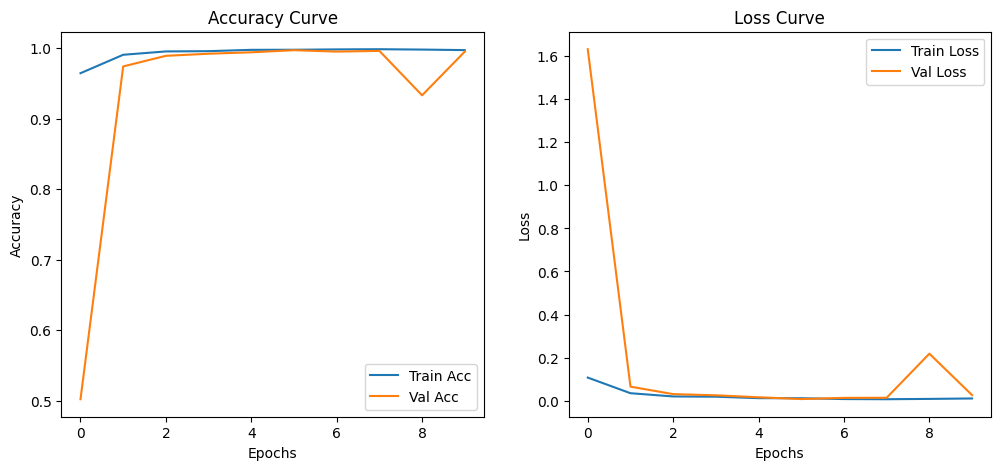

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 385ms/step


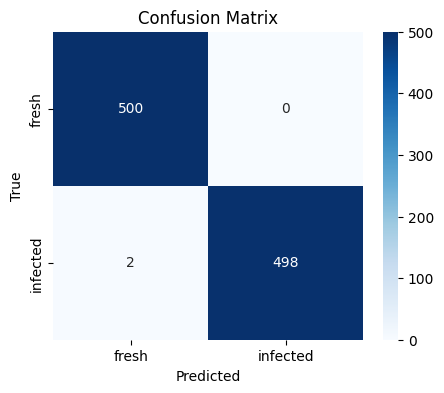


Classification Report:

              precision    recall  f1-score   support

       fresh     0.9960    1.0000    0.9980       500
    infected     1.0000    0.9960    0.9980       500

    accuracy                         0.9980      1000
   macro avg     0.9980    0.9980    0.9980      1000
weighted avg     0.9980    0.9980    0.9980      1000


🔹 Macro Average Accuracy (Precision Avg) : 0.9980
🔹 Overall Test Accuracy: 0.9980


In [4]:
#--------------------------
# CNN (Fresh vs Infected) - Complete with Macro Accuracy
# --------------------------
import os
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10   # change if needed

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# Refined CNN Model
# --------------------------
model_cnn = Sequential([
    Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(len(class_names), activation='softmax')
])

model_cnn.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_cnn_model.keras"  # future-proof format
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Loss & Accuracy
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data (with Macro Accuracy)
# --------------------------
y_pred = model_cnn.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy (Average Precision) & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
print(f"\n🔹 Macro Average Accuracy (Precision Avg) : {macro_accuracy:.4f}")

overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")



Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,146,946 (92.11 MB)

 Trainable params: 558,466 (2.13 MB)

 Non-trainable params: 23,588,480 (89.98 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 145s 514ms/step - accuracy: 0.7487 - loss: 0.5292 - val_accuracy: 0.5340 - val_loss: 0.6028
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 119s 476ms/step - accuracy: 0.8823 - loss: 0.2829 - val_accuracy: 0.8520 - val_loss: 0.3296
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 113s 452ms/step - accuracy: 0.9016 - loss: 0.2345 - val_accuracy: 0.7400 - val_loss: 0.4343
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 116s 461ms/step - accuracy: 0.9126 - loss: 0.2073 - val_accuracy: 0.8700 - val_loss: 0.2624
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 116s 463ms/step - accuracy: 0.9212 - loss: 0.1951 - val_accuracy: 0.8540 - val_loss: 0.3141
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 115s 461ms/step - accuracy: 0.9260 - loss: 0.1851 - val_accuracy: 0.9260 - val_loss: 0.1571
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 116s 464ms/step - accuracy: 0.9304 - loss: 0.1733 - val_accuracy: 0.9290 - val_loss: 0.1658
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 115s 461ms/step - accuracy: 0.9375 -

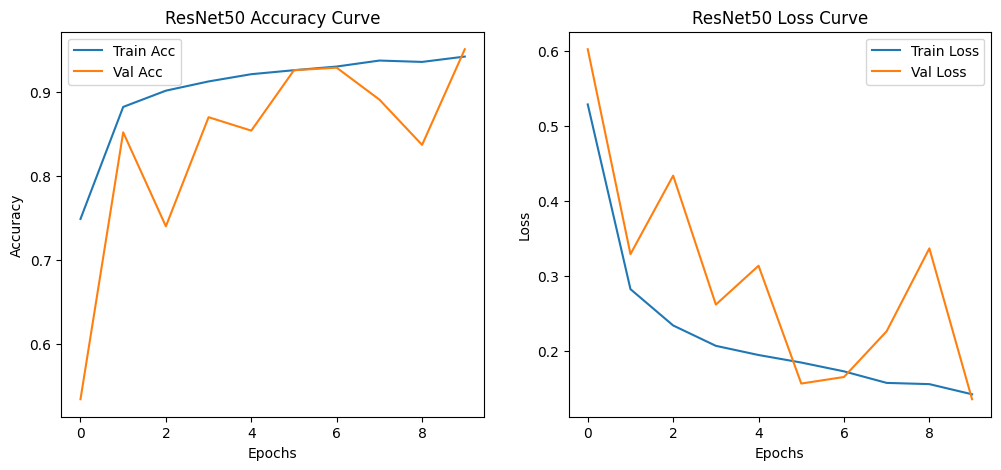

32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 554ms/step


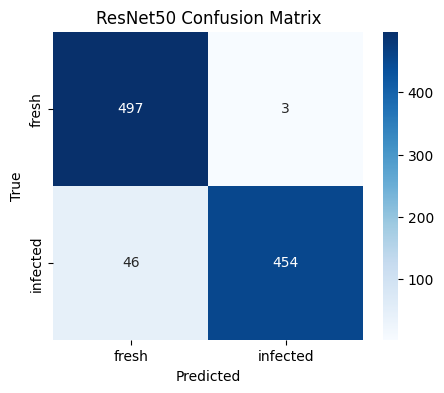


ResNet50 Classification Report:

              precision    recall  f1-score   support

       fresh     0.9153    0.9940    0.9530       500
    infected     0.9934    0.9080    0.9488       500

    accuracy                         0.9510      1000
   macro avg     0.9544    0.9510    0.9509      1000
weighted avg     0.9544    0.9510    0.9509      1000

🔹 ResNet50 Macro Average Accuracy: 0.9544
🔹 ResNet50 Overall Test Accuracy: 0.9510


In [4]:
import tensorflow as tf
import os

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Added for data generators

# Define output_dir and class_names (copied from cell wY9dhmNHFV4B)
output_dir = "/content/Final_split"
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))

# Data Generator parameters (copied from cell wY9dhmNHFV4B)
img_size = (224, 224)
batch_size = 32
epochs = 10

# Data Generators (copied from cell wY9dhmNHFV4B)
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# Base Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.5)(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation='softmax')(x)
model_resnet = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

model_resnet.compile(optimizer=Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_resnet.summary()

# Callbacks
checkpoint_path = "best_resnet50.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# Train
history = model_resnet.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks)

# Plot curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("ResNet50 Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("ResNet50 Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Evaluation
y_pred = model_resnet.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 Confusion Matrix")
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nResNet50 Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 ResNet50 Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 ResNet50 Overall Test Accuracy: {overall_acc:.4f}")

In [6]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files # Import Colab's file upload utility
from PIL import Image # Use PIL for image loading, as it's more flexible

# ==========================
# FILE PICKER (COLAB UPLOAD)
# ==========================
uploaded = files.upload() # Use Colab's file upload

# Get the filename of the uploaded file
if uploaded:
    img_path = list(uploaded.keys())[0]
    print("Selected file:", img_path)
else:
    print("No file selected. Please upload an image.")
    # Exit or handle the case where no file is uploaded
    # For now, let's assume a file is always uploaded for the rest of the code to run.
    # You might want to add more robust error handling here.
    exit()

# ==========================
# LOAD IMAGE
# ==========================
# Use PIL to open the image, then convert to array
img = Image.open(img_path).convert("RGB")
img = img.resize((224, 224)) # Resize to target_size
orig_img = np.array(img) # Store for overlay

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# ==========================
# BETTER LAYER
# ==========================
layer_name = "conv4_block6_out"

# ==========================
# GRAD-CAM
# ==========================
def gradcam(img_array, model, layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv, pred = grad_model(img_array)
        class_idx = tf.argmax(pred[0])
        loss = pred[:, class_idx]

    grads = tape.gradient(loss, conv)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))

    conv = conv[0]
    heatmap = conv @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

# ==========================
# HEATMAP
# ==========================
# IMPORTANT: Ensure 'model_resnet' is defined and loaded in a previous cell.
# If it's not, you'll need to load or define it here, for example:
# from tensorflow.keras.applications import ResNet50
# model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
# Add your custom top layers and load weights if necessary.
# For example, if you have saved your model as 'best_resnet50.keras':
# model_resnet = tf.keras.models.load_model('best_resnet50.keras')
heatmap = gradcam(img_array, model_resnet, layer_name)

heatmap = cv2.resize(heatmap, (224,224))

# ==========================
# 🔥 FIX 1: STRONG THRESHOLD (IMPORTANT)
# only top activations keep
# ==========================
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.GaussianBlur(heatmap, (5,5), 0)

_, heatmap = cv2.threshold(heatmap, 180, 255, cv2.THRESH_TOZERO)

# ==========================
# COLOR MAP
# ==========================
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# ==========================
# 🔥 FIX 2: LOWER ALPHA (VERY IMPORTANT)
# ==========================
overlay = cv2.addWeighted(orig_img, 0.75, heatmap_color, 0.25, 0)

# ==========================
# SIDE BY SIDE
# ==========================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(orig_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("Clean Grad-CAM (Fixed)")
plt.axis("off")

plt.show()

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.


KeyboardInterrupt



Saving 222.png to 222.png


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_547']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Prediction Scores: [[0.18764666 0.8123533 ]]
Predicted Class: 1


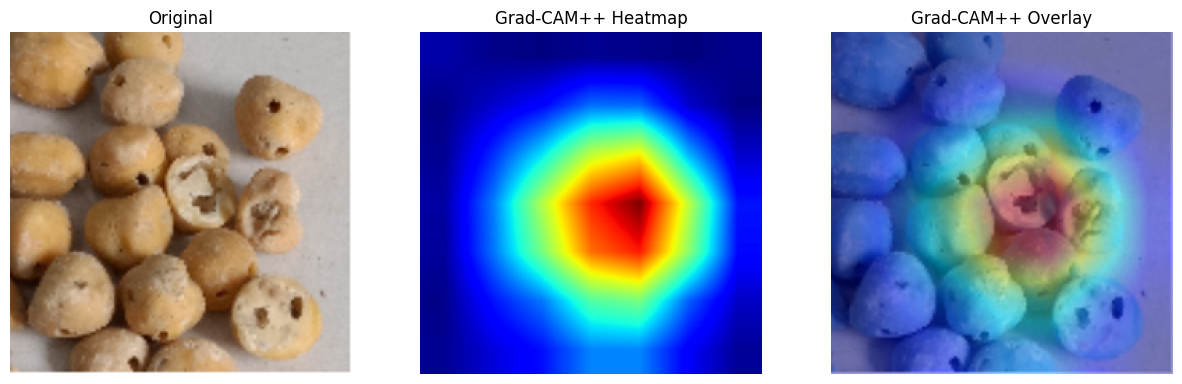

In [5]:
# ==========================================
# RESNET50 + TRUE GRAD-CAM++
# ==========================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from google.colab import files
from PIL import Image

# ==========================================
# Upload Image
# ==========================================

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ==========================================
# Load Image
# ==========================================

img = Image.open(img_path).convert("RGB")
img = img.resize((224,224))

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# ==========================================
# TRUE GRAD-CAM++
# ==========================================

def gradcam_plus_plus(model, img_array, layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output,
         model.output]
    )

    with tf.GradientTape() as tape1:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape3:

                conv_output, predictions = grad_model(img_array)

                class_idx = tf.argmax(predictions[0])

                score = predictions[:, class_idx]

            first_grad = tape3.gradient(score, conv_output)

        second_grad = tape2.gradient(first_grad, conv_output)

    third_grad = tape1.gradient(second_grad, conv_output)

    conv_output = conv_output[0]
    first_grad = first_grad[0]
    second_grad = second_grad[0]
    third_grad = third_grad[0]

    global_sum = tf.reduce_sum(
        conv_output,
        axis=(0,1)
    )

    alpha_num = second_grad

    alpha_denom = (
        2.0 * second_grad +
        third_grad * global_sum
    )

    alpha_denom = tf.where(
        alpha_denom != 0.0,
        alpha_denom,
        tf.ones_like(alpha_denom)
    )

    alphas = alpha_num / alpha_denom

    alpha_norm = tf.reduce_sum(
        alphas,
        axis=(0,1),
        keepdims=True
    )

    alphas = alphas / (alpha_norm + 1e-10)

    positive_gradients = tf.nn.relu(first_grad)

    weights = tf.reduce_sum(
        alphas * positive_gradients,
        axis=(0,1)
    )

    cam = tf.reduce_sum(
        weights * conv_output,
        axis=-1
    )

    cam = tf.nn.relu(cam)

    cam = cam.numpy()

    cam = cv2.resize(cam, (224,224))

    cam = cam - np.min(cam)
    cam = cam / (np.max(cam) + 1e-8)

    return cam

# ==========================================
# Generate Heatmap
# ==========================================

last_conv_layer = "conv5_block3_out"

heatmap = gradcam_plus_plus(
    model_resnet,
    img_array,
    last_conv_layer
)

# ==========================================
# Prediction
# ==========================================

pred = model_resnet.predict(img_array, verbose=0)

print("Prediction Scores:", pred)

pred_class = np.argmax(pred)

print("Predicted Class:", pred_class)

# ==========================================
# Heatmap Overlay
# ==========================================

img_display = (img_array[0] * 255).astype(np.uint8)

heatmap_uint8 = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    img_display,
    0.6,
    heatmap_color,
    0.4,
    0
)

# ==========================================
# Plot Results
# ==========================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_display)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM++ Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM++ Overlay")
plt.axis("off")

plt.show()

Saving Screenshot_2.png to Screenshot_2 (1).png


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_547']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Prediction: [[0.07790365 0.9220963 ]]
Predicted Class: 1


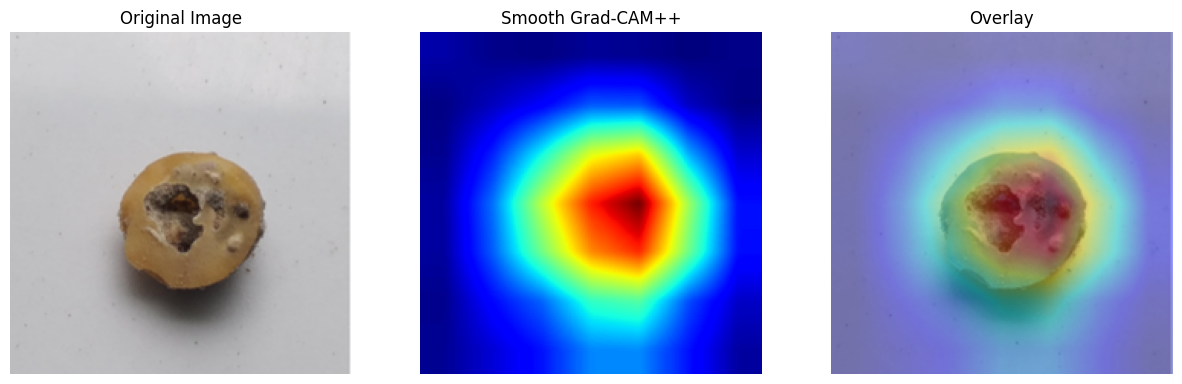

In [8]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# ==========================================
# Upload Image
# ==========================================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ==========================================
# Preprocess Image
# ==========================================
img = Image.open(img_path).convert("RGB").resize((224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# ==========================================
# SMOOTH GRAD-CAM++
# ==========================================
def smooth_gradcam_plus_plus(model, img_array, layer_name, eps=1e-8):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    # REVISED: Using nested GradientTapes for higher-order gradients
    with tf.GradientTape() as tape1:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape3:
                conv_output, predictions = grad_model(img_array)

                class_idx = tf.argmax(predictions[0])
                score = predictions[:, class_idx]

            # First order gradient: d(score)/d(conv_output)
            grads = tape3.gradient(score, conv_output)

        # Second order gradient: d(grads)/d(conv_output)
        grads2 = tape2.gradient(grads, conv_output)

    # Third order gradient: d(grads2)/d(conv_output)
    grads3 = tape1.gradient(grads2, conv_output)

    conv_output = conv_output[0]
    grads = grads[0]
    grads2 = grads2[0]
    grads3 = grads3[0]

    global_sum = tf.reduce_sum(conv_output, axis=(0, 1))

    alpha_num = grads2
    alpha_denom = 2.0 * grads2 + grads3 * global_sum

    alpha_denom = tf.where(alpha_denom != 0, alpha_denom, tf.ones_like(alpha_denom))
    alphas = alpha_num / alpha_denom

    alphas = alphas / (tf.reduce_sum(alphas, axis=(0,1), keepdims=True) + eps)

    weights = tf.reduce_sum(alphas * tf.nn.relu(grads), axis=(0,1))

    cam = tf.reduce_sum(weights * conv_output, axis=-1)
    cam = tf.nn.relu(cam).numpy()

    # Resize + Normalize
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + eps)

    # Smooth heatmap (IMPORTANT)
    cam = cv2.GaussianBlur(cam, (7, 7), 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + eps)

    return cam

# ==========================================
# Run Grad-CAM++
# ==========================================
last_conv_layer = "conv5_block3_out"

heatmap = smooth_gradcam_plus_plus(
    model_resnet,
    img_array,
    last_conv_layer
)

# ==========================================
# Prediction
# ==========================================
pred = model_resnet.predict(img_array, verbose=0)
pred_class = np.argmax(pred)

print("Prediction:", pred)
print("Predicted Class:", pred_class)

# ==========================================
# Overlay
# ==========================================
img_display = (img_array[0] * 255).astype(np.uint8)

heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img_display, 0.6, heatmap_color, 0.4, 0)
overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# ==========================================
# Plot
# ==========================================
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_display)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Smooth Grad-CAM++")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

Saving Screenshot_5.png to Screenshot_5.png
Prediction Scores: [[0.21704526 0.7829548 ]]
Predicted Class: 1


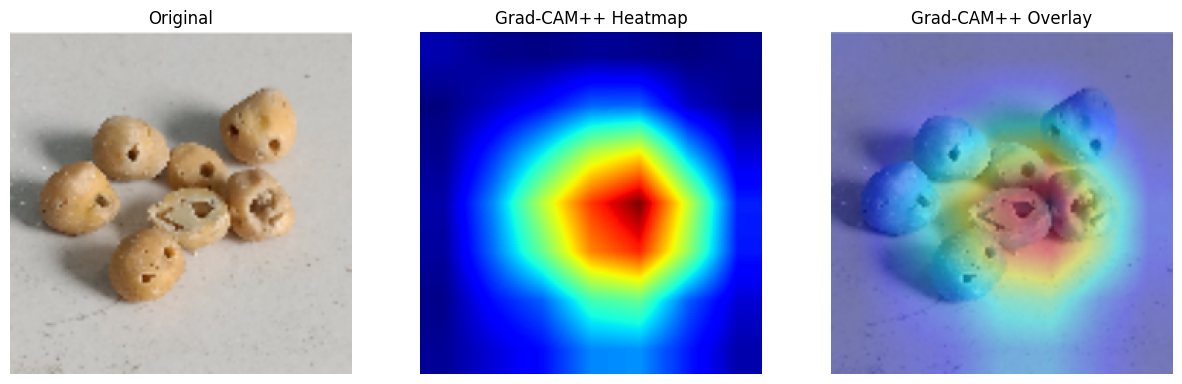

In [6]:
# ==========================================
# RESNET50 + TRUE GRAD-CAM++
# ==========================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from google.colab import files
from PIL import Image

# ==========================================
# Upload Image
# ==========================================

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ==========================================
# Load Image
# ==========================================

img = Image.open(img_path).convert("RGB")
img = img.resize((224,224))

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# ==========================================
# TRUE GRAD-CAM++
# ==========================================

def gradcam_plus_plus(model, img_array, layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output,
         model.output]
    )

    with tf.GradientTape() as tape1:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape3:

                conv_output, predictions = grad_model(img_array)

                class_idx = tf.argmax(predictions[0])

                score = predictions[:, class_idx]

            first_grad = tape3.gradient(score, conv_output)

        second_grad = tape2.gradient(first_grad, conv_output)

    third_grad = tape1.gradient(second_grad, conv_output)

    conv_output = conv_output[0]
    first_grad = first_grad[0]
    second_grad = second_grad[0]
    third_grad = third_grad[0]

    global_sum = tf.reduce_sum(
        conv_output,
        axis=(0,1)
    )

    alpha_num = second_grad

    alpha_denom = (
        2.0 * second_grad +
        third_grad * global_sum
    )

    alpha_denom = tf.where(
        alpha_denom != 0.0,
        alpha_denom,
        tf.ones_like(alpha_denom)
    )

    alphas = alpha_num / alpha_denom

    alpha_norm = tf.reduce_sum(
        alphas,
        axis=(0,1),
        keepdims=True
    )

    alphas = alphas / (alpha_norm + 1e-10)

    positive_gradients = tf.nn.relu(first_grad)

    weights = tf.reduce_sum(
        alphas * positive_gradients,
        axis=(0,1)
    )

    cam = tf.reduce_sum(
        weights * conv_output,
        axis=-1
    )

    cam = tf.nn.relu(cam)

    cam = cam.numpy()

    cam = cv2.resize(cam, (224,224))

    cam = cam - np.min(cam)
    cam = cam / (np.max(cam) + 1e-8)

    return cam

# ==========================================
# Generate Heatmap
# ==========================================

last_conv_layer = "conv5_block3_out"

heatmap = gradcam_plus_plus(
    model_resnet,
    img_array,
    last_conv_layer
)

# ==========================================
# Prediction
# ==========================================

pred = model_resnet.predict(img_array, verbose=0)

print("Prediction Scores:", pred)

pred_class = np.argmax(pred)

print("Predicted Class:", pred_class)

# ==========================================
# Heatmap Overlay
# ==========================================

img_display = (img_array[0] * 255).astype(np.uint8)

heatmap_uint8 = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    img_display,
    0.6,
    heatmap_color,
    0.4,
    0
)

# ==========================================
# Plot Results
# ==========================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_display)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM++ Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM++ Overlay")
plt.axis("off")

plt.show()

Saving img_714.jpg to img_714 (2).jpg
Prediction Scores: [[0.15138923 0.84861076]]
Predicted Class: 1


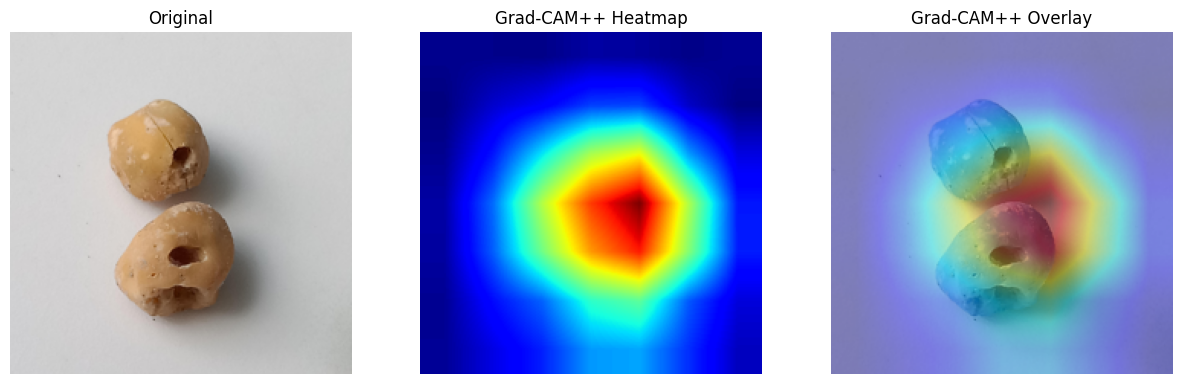

In [ ]:
# ==========================================
# RESNET50 + TRUE GRAD-CAM++
# ==========================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from google.colab import files
from PIL import Image

# ==========================================
# Upload Image
# ==========================================

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ==========================================
# Load Image
# ==========================================

img = Image.open(img_path).convert("RGB")
img = img.resize((224,224))

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# ==========================================
# TRUE GRAD-CAM++
# ==========================================

def gradcam_plus_plus(model, img_array, layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output,
         model.output]
    )

    with tf.GradientTape() as tape1:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape3:

                conv_output, predictions = grad_model(img_array)

                class_idx = tf.argmax(predictions[0])

                score = predictions[:, class_idx]

            first_grad = tape3.gradient(score, conv_output)

        second_grad = tape2.gradient(first_grad, conv_output)

    third_grad = tape1.gradient(second_grad, conv_output)

    conv_output = conv_output[0]
    first_grad = first_grad[0]
    second_grad = second_grad[0]
    third_grad = third_grad[0]

    global_sum = tf.reduce_sum(
        conv_output,
        axis=(0,1)
    )

    alpha_num = second_grad

    alpha_denom = (
        2.0 * second_grad +
        third_grad * global_sum
    )

    alpha_denom = tf.where(
        alpha_denom != 0.0,
        alpha_denom,
        tf.ones_like(alpha_denom)
    )

    alphas = alpha_num / alpha_denom

    alpha_norm = tf.reduce_sum(
        alphas,
        axis=(0,1),
        keepdims=True
    )

    alphas = alphas / (alpha_norm + 1e-10)

    positive_gradients = tf.nn.relu(first_grad)

    weights = tf.reduce_sum(
        alphas * positive_gradients,
        axis=(0,1)
    )

    cam = tf.reduce_sum(
        weights * conv_output,
        axis=-1
    )

    cam = tf.nn.relu(cam)

    cam = cam.numpy()

    cam = cv2.resize(cam, (224,224))

    cam = cam - np.min(cam)
    cam = cam / (np.max(cam) + 1e-8)

    return cam

# ==========================================
# Generate Heatmap
# ==========================================

last_conv_layer = "conv5_block3_out"

heatmap = gradcam_plus_plus(
    model_resnet,
    img_array,
    last_conv_layer
)

# ==========================================
# Prediction
# ==========================================

pred = model_resnet.predict(img_array, verbose=0)

print("Prediction Scores:", pred)

pred_class = np.argmax(pred)

print("Predicted Class:", pred_class)

# ==========================================
# Heatmap Overlay
# ==========================================

img_display = (img_array[0] * 255).astype(np.uint8)

heatmap_uint8 = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    img_display,
    0.6,
    heatmap_color,
    0.4,
    0
)

# ==========================================
# Plot Results
# ==========================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_display)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM++ Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM++ Overlay")
plt.axis("off")

plt.show()

Saving img_714.jpg to img_714 (2).jpg
Prediction Scores: [[0.15138923 0.84861076]]
Predicted Class: 1


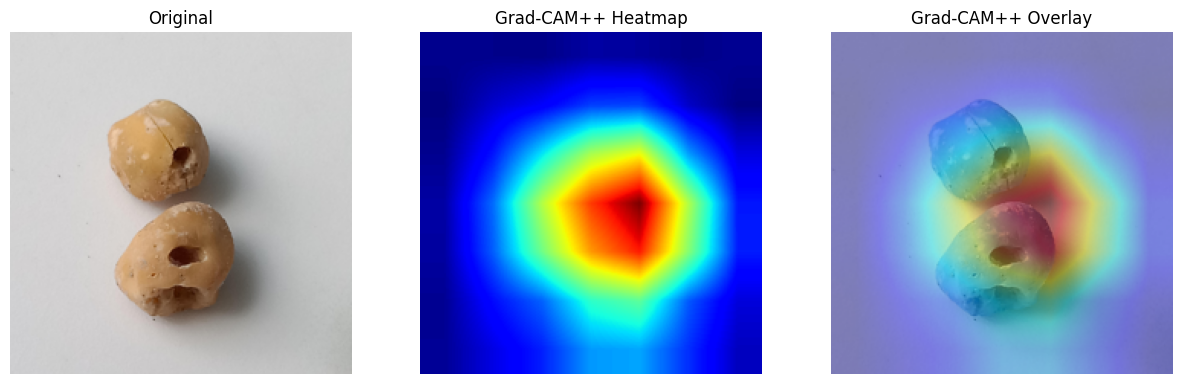

In [ ]:
# ==========================================
# RESNET50 + TRUE GRAD-CAM++
# ==========================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from google.colab import files
from PIL import Image

# ==========================================
# Upload Image
# ==========================================

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ==========================================
# Load Image
# ==========================================

img = Image.open(img_path).convert("RGB")
img = img.resize((224,224))

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# ==========================================
# TRUE GRAD-CAM++
# ==========================================

def gradcam_plus_plus(model, img_array, layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output,
         model.output]
    )

    with tf.GradientTape() as tape1:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape3:

                conv_output, predictions = grad_model(img_array)

                class_idx = tf.argmax(predictions[0])

                score = predictions[:, class_idx]

            first_grad = tape3.gradient(score, conv_output)

        second_grad = tape2.gradient(first_grad, conv_output)

    third_grad = tape1.gradient(second_grad, conv_output)

    conv_output = conv_output[0]
    first_grad = first_grad[0]
    second_grad = second_grad[0]
    third_grad = third_grad[0]

    global_sum = tf.reduce_sum(
        conv_output,
        axis=(0,1)
    )

    alpha_num = second_grad

    alpha_denom = (
        2.0 * second_grad +
        third_grad * global_sum
    )

    alpha_denom = tf.where(
        alpha_denom != 0.0,
        alpha_denom,
        tf.ones_like(alpha_denom)
    )

    alphas = alpha_num / alpha_denom

    alpha_norm = tf.reduce_sum(
        alphas,
        axis=(0,1),
        keepdims=True
    )

    alphas = alphas / (alpha_norm + 1e-10)

    positive_gradients = tf.nn.relu(first_grad)

    weights = tf.reduce_sum(
        alphas * positive_gradients,
        axis=(0,1)
    )

    cam = tf.reduce_sum(
        weights * conv_output,
        axis=-1
    )

    cam = tf.nn.relu(cam)

    cam = cam.numpy()

    cam = cv2.resize(cam, (224,224))

    cam = cam - np.min(cam)
    cam = cam / (np.max(cam) + 1e-8)

    return cam

# ==========================================
# Generate Heatmap
# ==========================================

last_conv_layer = "conv5_block3_out"

heatmap = gradcam_plus_plus(
    model_resnet,
    img_array,
    last_conv_layer
)

# ==========================================
# Prediction
# ==========================================

pred = model_resnet.predict(img_array, verbose=0)

print("Prediction Scores:", pred)

pred_class = np.argmax(pred)

print("Predicted Class:", pred_class)

# ==========================================
# Heatmap Overlay
# ==========================================

img_display = (img_array[0] * 255).astype(np.uint8)

heatmap_uint8 = np.uint8(255 * heatmap)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(
    img_display,
    0.6,
    heatmap_color,
    0.4,
    0
)

# ==========================================
# Plot Results
# ==========================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_display)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM++ Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM++ Overlay")
plt.axis("off")

plt.show()

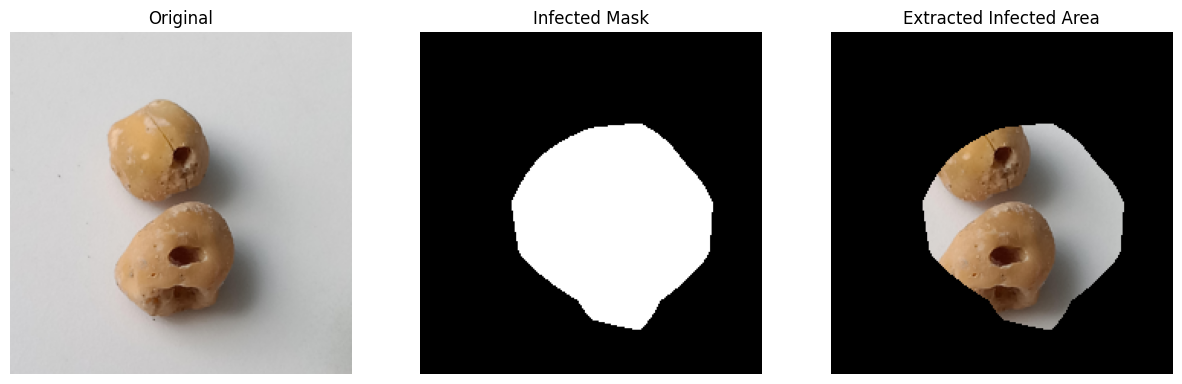

In [ ]:
# ==========================================
# STEP 1: Normalize Heatmap
# ==========================================

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() + 1e-8)

# ==========================================
# STEP 2: Threshold (IMPORTANT PART)
# ==========================================

# Option 1: fixed threshold (best for control)
thresh_value = 0.5

# Option 2 (better): automatic Otsu threshold
heatmap_uint8 = np.uint8(255 * heatmap_resized)
_, binary_mask = cv2.threshold(heatmap_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ==========================================
# STEP 3: Clean Mask (remove noise)
# ==========================================

kernel = np.ones((5,5), np.uint8)

binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

# ==========================================
# STEP 4: Extract ONLY infected region
# ==========================================

original = img_display.copy()

infected_region = cv2.bitwise_and(original, original, mask=binary_mask)

# ==========================================
# STEP 5: Draw Contours (optional but powerful)
# ==========================================

contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

boxed = original.copy()

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(boxed, (x, y), (x+w, y+h), (0,255,0), 2)

# ==========================================
# STEP 6: Plot Results
# ==========================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap="gray")
plt.title("Infected Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(infected_region)
plt.title("Extracted Infected Area")
plt.axis("off")

plt.show()

Saving img_069.jpg to img_069.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: [[0.03425398 0.965746  ]]
Class: 1


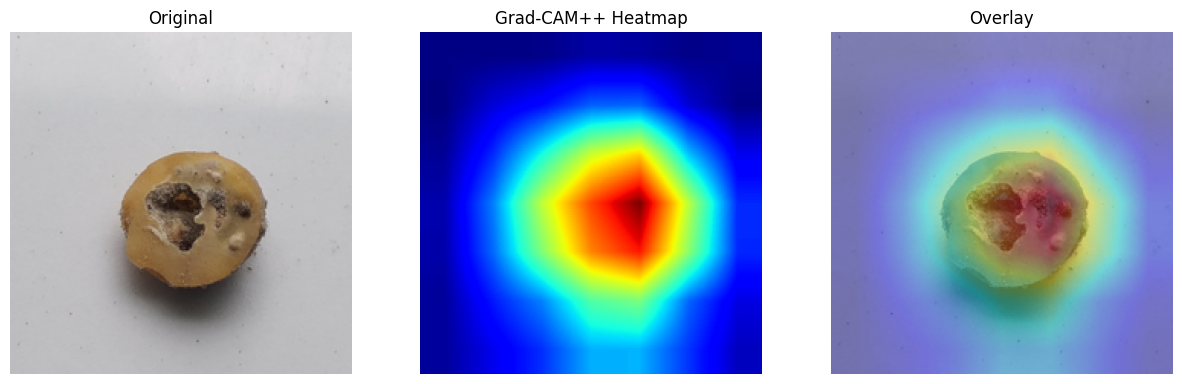

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# ==========================================
# Upload Image
# ==========================================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ==========================================
# Load Image
# ==========================================
img = Image.open(img_path).convert("RGB")
img = img.resize((224, 224))

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# ==========================================
# GRAD-CAM++
# ==========================================
def gradcam_plus_plus(model, img_array, layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape1:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape3:

                conv_out, preds = grad_model(img_array)
                class_idx = tf.argmax(preds[0])
                score = preds[:, class_idx]

            first_grad = tape3.gradient(score, conv_out)

        second_grad = tape2.gradient(first_grad, conv_out)

    third_grad = tape1.gradient(second_grad, conv_out)

    conv_out = conv_out[0]
    first_grad = first_grad[0]
    second_grad = second_grad[0]
    third_grad = third_grad[0]

    global_sum = tf.reduce_sum(conv_out, axis=(0,1))

    alpha_num = second_grad
    alpha_denom = 2.0 * second_grad + third_grad * global_sum

    alpha_denom = tf.where(alpha_denom != 0.0,
                           alpha_denom,
                           tf.ones_like(alpha_denom))

    alphas = alpha_num / alpha_denom

    alphas = alphas / (tf.reduce_sum(alphas, axis=(0,1), keepdims=True) + 1e-10)

    relu_grad = tf.nn.relu(first_grad)

    weights = tf.reduce_sum(alphas * relu_grad, axis=(0,1))

    cam = tf.reduce_sum(weights * conv_out, axis=-1)

    cam = tf.nn.relu(cam).numpy()

    cam = cv2.resize(cam, (224, 224))

    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    return cam

# ==========================================
# Load your trained model
# ==========================================
# model_resnet = tf.keras.models.load_model("your_model.h5")

last_conv_layer = "conv5_block3_out"

# ==========================================
# Generate Heatmap
# ==========================================
heatmap = gradcam_plus_plus(model_resnet, img_array, last_conv_layer)

# ==========================================
# Prediction
# ==========================================
pred = model_resnet.predict(img_array)
print("Prediction:", pred)
print("Class:", np.argmax(pred))

# ==========================================
# Overlay
# ==========================================
img_disp = (img_array[0] * 255).astype(np.uint8)

heat_uint8 = np.uint8(255 * heatmap)
heat_color = cv2.applyColorMap(heat_uint8, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img_disp, 0.6, heat_color, 0.4, 0)

# ==========================================
# Plot
# ==========================================
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_disp)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM++ Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Overlay")
plt.axis("off")

plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Saving img_069.jpg to img_069 (1).jpg
Uploaded: img_069 (1).jpg


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━

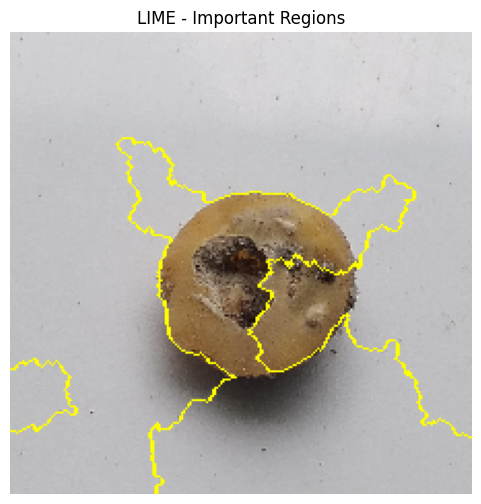

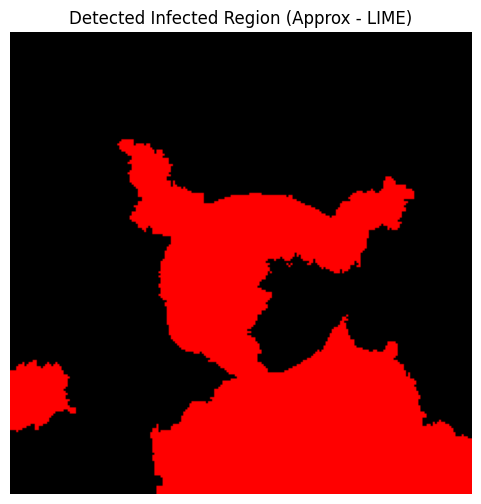

In [ ]:
# ==========================
# INSTALL LIME
# ==========================
!pip install lime -q

# ==========================
# IMPORT LIBRARIES
# ==========================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

from google.colab import files
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications.resnet50 import preprocess_input

# ==========================
# STEP 1: UPLOAD IMAGE FROM PC
# ==========================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

print("Uploaded:", img_path)

# ==========================
# STEP 2: LOAD IMAGE
# ==========================
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

image_for_lime = img.copy()

# ==========================
# STEP 3: LOAD MODEL
# (Replace with your trained model if needed)
# ==========================
model = tf.keras.applications.ResNet50(weights="imagenet")

# ==========================
# STEP 4: PREDICTION FUNCTION
# ==========================
def predict_fn(images):
    images = np.array(images)
    images = preprocess_input(images)
    return model.predict(images)

# ==========================
# STEP 5: LIME EXPLAINER
# ==========================
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image_for_lime,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# ==========================
# STEP 6: GET INFECTED REGION MASK
# ==========================
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

# ==========================
# STEP 7: VISUALIZATION - 1 (BOUNDARY)
# ==========================
plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME - Important Regions")
plt.axis("off")
plt.show()

# ==========================
# STEP 8: VISUALIZATION - 2 (INFECTED REGION ONLY RED)
# ==========================
highlight = img.copy()

# background black
highlight[mask == 0] = [0, 0, 0]

# infected region red
highlight[mask == 1] = [255, 0, 0]

plt.figure(figsize=(6,6))
plt.imshow(highlight)
plt.title("Detected Infected Region (Approx - LIME)")
plt.axis("off")
plt.show()

In [ ]:
# ==========================# INSTALL# ==========================!pip install lime -qimport numpy as npimport matplotlib.pyplot as pltimport tensorflow as tfimport cv2from google.colab import filesfrom lime import lime_imagefrom skimage.segmentation import mark_boundariesfrom tensorflow.keras.applications.resnet50 import preprocess_input# ==========================# UPLOAD IMAGE# ==========================uploaded = files.upload()img_path = list(uploaded.keys())[0]# ==========================# LOAD IMAGE# ==========================img = cv2.imread(img_path)img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)img = cv2.resize(img, (224, 224))orig = img.copy()# ==========================# MODEL (replace with your trained model)# ==========================model = tf.keras.applications.ResNet50(weights="imagenet")# ==========================# PREDICT FUNCTION# ==========================# ==========================def predict_fn(images):    images = np.array(images)    images = preprocess_input(images)    return model.predict(images)# ==========================# LIME EXPLAINER# ==========================explainer = lime_image.LimeImageExplainer()explanation = explainer.explain_instance(    img,    predict_fn,    top_labels=1,    hide_color=0,    num_samples=1000)# ==========================# GET MASK (IMPORTANT REGION)# ==========================temp, mask = explanation.get_image_and_mask(    label=explanation.top_labels[0],    positive_only=True,    num_features=12,    hide_rest=False)# ==========================# STEP 1: OBJECT CUT (REMOVE BACKGROUND)# ==========================object_only = orig.copy()object_only[mask == 0] = 0   # background remove# ==========================# STEP 2: INFECTED REGION HIGHLIGHT INSIDE OBJECT# ==========================infected = object_only.copy()# red overlay for important regioninfected_mask = (mask == 1)infected[infected_mask] = [255, 0, 0]# ==========================# VISUALIZATION# ==========================plt.figure(figsize=(6,6))plt.imshow(orig)plt.title("Original Image")plt.axis("off")plt.show()plt.figure(figsize=(6,6))plt.imshow(object_only)plt.title("Object Extracted (Background Removed)")plt.axis("off")plt.show()plt.figure(figsize=(6,6)) # Corrected from figsize=(66)plt.imshow(infected)plt.title("Infected Region Inside Object (Red Highlight)")plt.axis("off")plt.show()

Saving img_069.jpg to img_069 (3).jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_928']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━

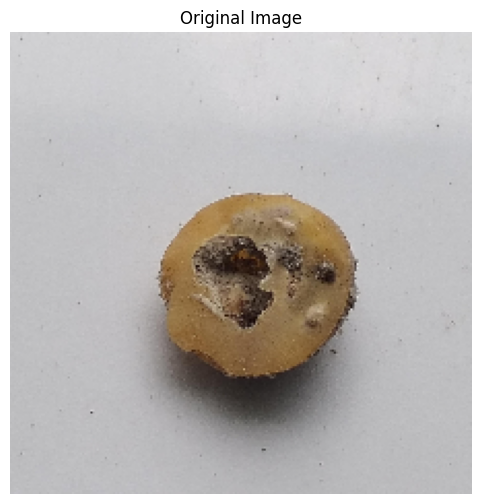

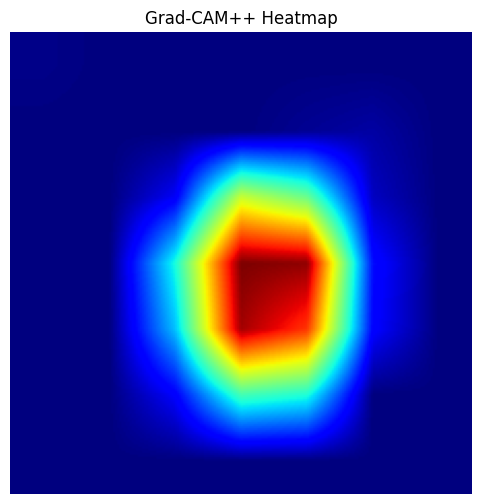

ValueError: Invalid integer data type 'f'.

<Figure size 600x600 with 0 Axes>

In [ ]:
# ==========================
# INSTALL LIME
# ==========================
!pip install lime -q

# ==========================
# IMPORTS
# ==========================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

from google.colab import files
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications.resnet50 import preprocess_input

# ==========================
# UPLOAD IMAGE
# ==========================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ==========================
# LOAD IMAGE
# ==========================
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
orig = img.copy()

# ==========================
# LOAD MODEL (replace with your trained model)
# ==========================
model = tf.keras.applications.ResNet50(weights="imagenet")

# ==========================
# --------------------------
# GRAD-CAM++
# --------------------------
# ==========================
last_conv_layer = "conv5_block3_out"

grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer).output, model.output]
)

def gradcam_heatmap(image):
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(image)
        pred_index = tf.argmax(preds[0])
        loss = preds[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

heatmap = gradcam_heatmap(orig)

heatmap_resized = cv2.resize(heatmap, (224, 224))

# ==========================
# --------------------------
# LIME
# --------------------------
# ==========================

def predict_fn(images):
    images = np.array(images)
    images = preprocess_input(images)
    return model.predict(images)

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    orig,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

_, lime_mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

# ==========================
# HYBRID FUSION (MAIN STEP)
# ==========================

lime_mask = lime_mask.astype(np.float32)

# normalize gradcam
gradcam_mask = heatmap_resized

# combine both (weighted fusion)
hybrid = (0.5 * lime_mask + 0.5 * gradcam_mask)

hybrid = hybrid / np.max(hybrid)

# ==========================
# OBJECT EXTRACTION
# ==========================
object_only = orig.copy()
binary_mask = hybrid > 0.3

object_only[~binary_mask] = 0

# ==========================
# INFECTED REGION HIGHLIGHT
# ==========================
highlight = orig.copy()

highlight[binary_mask] = [255, 0, 0]

# ==========================
# VISUALIZATION
# ==========================

plt.figure(figsize=(6,6))
plt.imshow(orig)
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM++ Heatmap")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(orig, lime_mask))
plt.title("LIME Superpixel Importance")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(object_only)
plt.title("Object Extracted (Hybrid Mask)")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(highlight)
plt.title("Final Infected Region (Hybrid LIME + Grad-CAM++)")
plt.axis("off")
plt.show()

Saving img_713.jpg to img_713 (1).jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1282']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━

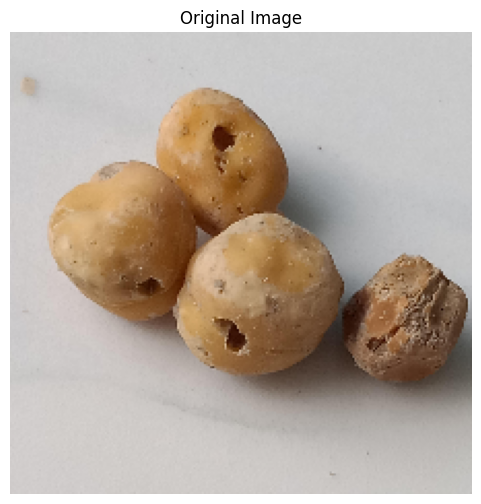

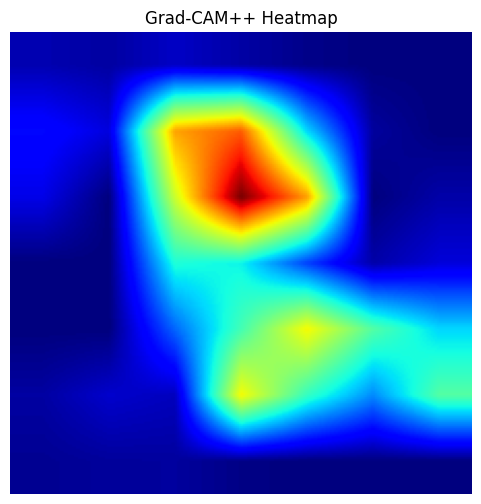

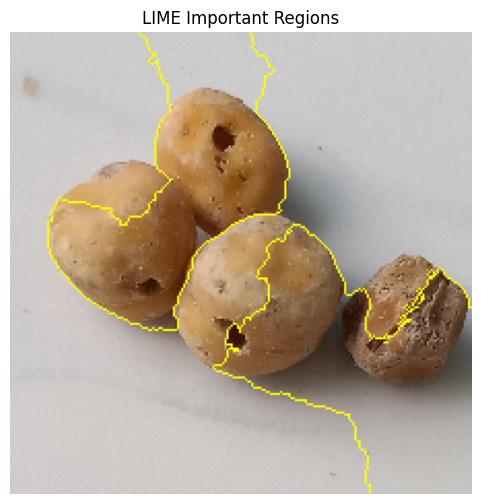

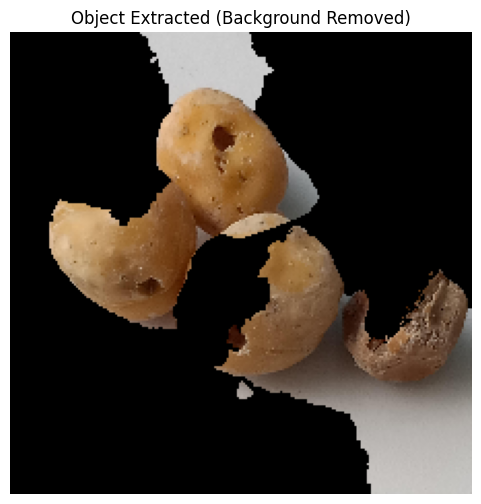

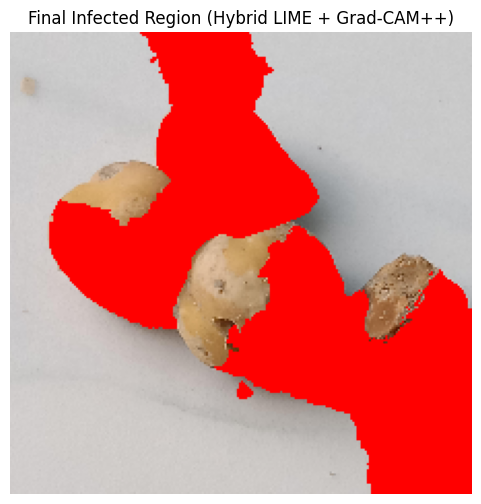

In [ ]:
# ==========================
# INSTALL LIME
# ==========================
!pip install lime -q

# ==========================
# IMPORT LIBRARIES
# ==========================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

from google.colab import files
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications.resnet50 import preprocess_input

# ==========================
# STEP 1: UPLOAD IMAGE
# ==========================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ==========================
# STEP 2: LOAD IMAGE
# ==========================
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
orig = img.copy()

# ==========================
# STEP 3: LOAD MODEL (replace with your trained model)
# ==========================
model = tf.keras.applications.ResNet50(weights="imagenet")

# ==========================
# ==========================
# GRAD-CAM++
# ==========================
# ==========================
last_conv_layer = "conv5_block3_out"

grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer).output, model.output]
)

def gradcam_heatmap(image):
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(image)
        pred_index = tf.argmax(preds[0])
        loss = preds[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

heatmap = gradcam_heatmap(orig)
heatmap = cv2.resize(heatmap, (224, 224))

# ==========================
# ==========================
# LIME
# ==========================
# ==========================

def predict_fn(images):
    images = np.array(images)
    images = preprocess_input(images)
    return model.predict(images)

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    orig,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

_, lime_mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

# ==========================
# FIX LIME MASK TYPE (IMPORTANT FIX)
# ==========================
lime_mask = lime_mask.astype(np.int32)

# ==========================
# ==========================
# HYBRID FUSION
# ==========================
# ==========================

gradcam_mask = heatmap

# normalize both
lime_mask_norm = lime_mask / (np.max(lime_mask) + 1e-8)
gradcam_norm = gradcam_mask / (np.max(gradcam_mask) + 1e-8)

hybrid = 0.5 * lime_mask_norm + 0.5 * gradcam_norm
hybrid = hybrid / (np.max(hybrid) + 1e-8)

# ==========================
# OBJECT EXTRACTION
# ==========================
binary_mask = hybrid > 0.3

object_only = orig.copy()
object_only[~binary_mask] = 0

# ==========================
# INFECTED REGION HIGHLIGHT
# ==========================
highlight = orig.copy()
highlight[binary_mask] = [255, 0, 0]

# ==========================
# ==========================
# VISUALIZATION
# ==========================
# ==========================

plt.figure(figsize=(6,6))
plt.imshow(orig)
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM++ Heatmap")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(orig / 255.0, lime_mask))
plt.title("LIME Important Regions")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(object_only)
plt.title("Object Extracted (Background Removed)")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(highlight)
plt.title("Final Infected Region (Hybrid LIME + Grad-CAM++)")
plt.axis("off")
plt.show()

Saving img_714.jpg to img_714 (4).jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1636']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


  0%|          | 0/2000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


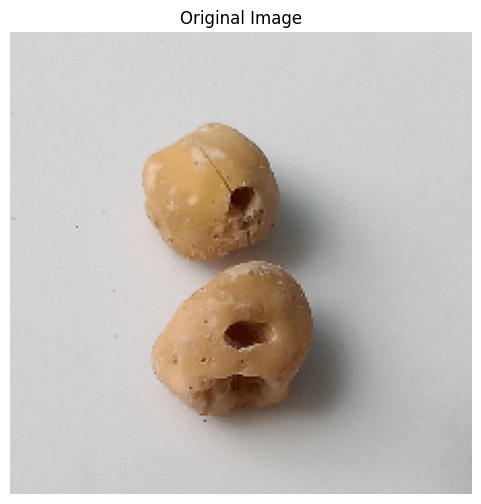

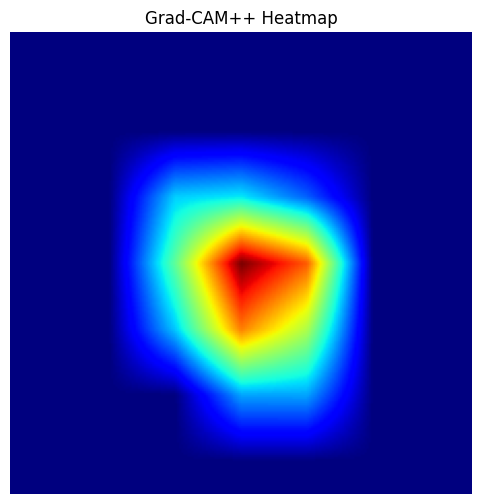

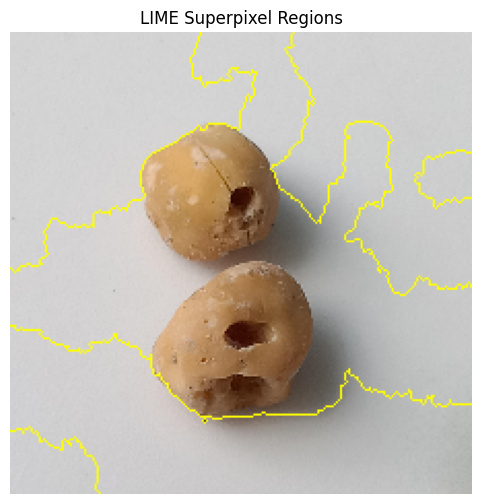

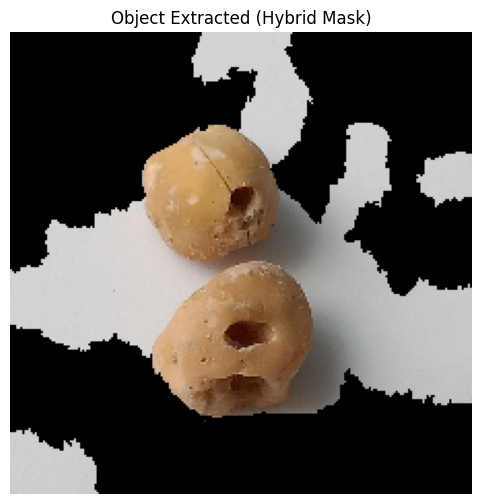

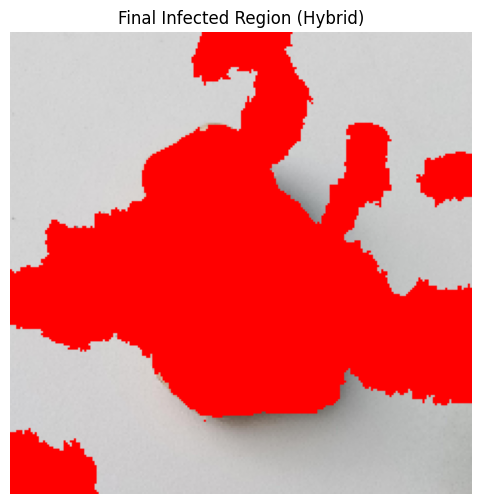

In [ ]:
# ==========================
# INSTALL LIME
# ==========================
!pip install lime -q

# ==========================
# IMPORTS
# ==========================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

from google.colab import files
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.applications.resnet50 import preprocess_input

# ==========================
# STEP 1: UPLOAD IMAGE
# ==========================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ==========================
# STEP 2: LOAD IMAGE
# ==========================
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
orig = img.copy()

# ==========================
# STEP 3: LOAD YOUR MODEL (IMPORTANT)
# ==========================
# 🔴 Replace this with YOUR trained model
# model = tf.keras.models.load_model("/content/your_model.h5")

model = tf.keras.applications.ResNet50(weights="imagenet")  # temporary fallback

# ==========================
# ==========================
# GRAD-CAM++
# ==========================
# ==========================

last_conv_layer = "conv5_block3_out"

grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer).output, model.output]
)

def gradcam_heatmap(image):
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(image)
        pred_index = tf.argmax(preds[0])
        loss = preds[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

heatmap = gradcam_heatmap(orig)
heatmap = cv2.resize(heatmap, (224, 224))

# ==========================
# ==========================
# LIME (FIXED VERSION)
# ==========================
# ==========================

def predict_fn(images):
    images = np.array(images)
    images = preprocess_input(images)
    return model.predict(images)

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    orig,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=2000
)

_, lime_mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    num_features=15,
    hide_rest=False
)

lime_mask = lime_mask.astype(np.int32)
lime_mask = (lime_mask > 0).astype(np.float32)

# ==========================
# ==========================
# HYBRID FUSION
# ==========================
# ==========================

gradcam_norm = heatmap / (np.max(heatmap) + 1e-8)

lime_resized = cv2.resize(lime_mask, (224, 224))

hybrid = 0.6 * gradcam_norm + 0.4 * lime_resized
hybrid = hybrid / (np.max(hybrid) + 1e-8)

# ==========================
# OBJECT EXTRACTION
# ==========================
binary_mask = hybrid > 0.35

object_only = orig.copy()
object_only[~binary_mask] = 0

# ==========================
# INFECTED REGION HIGHLIGHT
# ==========================
highlight = orig.copy()
highlight[binary_mask] = [255, 0, 0]

# ==========================
# ==========================
# VISUALIZATION
# ==========================
# ==========================

plt.figure(figsize=(6,6))
plt.imshow(orig)
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM++ Heatmap")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(orig / 255.0, lime_mask.astype(np.int32)))
plt.title("LIME Superpixel Regions")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(object_only)
plt.title("Object Extracted (Hybrid Mask)")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(highlight)
plt.title("Final Infected Region (Hybrid)")
plt.axis("off")
plt.show()